# Airbnb Market Intelligence

# 02 - Bivariate Exploratory Data Analysis (EDA)

## Objectives

- Analyze relationships between two variables
- Identify factors affecting Airbnb prices
- Compare ratings across categories
- Generate business insights

## 01 - Import libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## 02 - Load dataset

In [2]:
df = pd.read_csv("../data/cleaned/listings_cleaned.csv")

print(df.shape)

df.head()

(279712, 32)


,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",Unknown,1.0,0.98,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


## 03 - Basic information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279712 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                279712 non-null  object 
 5   host_response_time           279712 non-null  object 
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_is_superhost            279712 non-null  object 
 9   host_total_listings_count    279712 non-null  float64
 10  host_has_profile_pic         279712 non-null  object 
 11  host_identity_verified       279712 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

## 05 - Price vs Bedroom

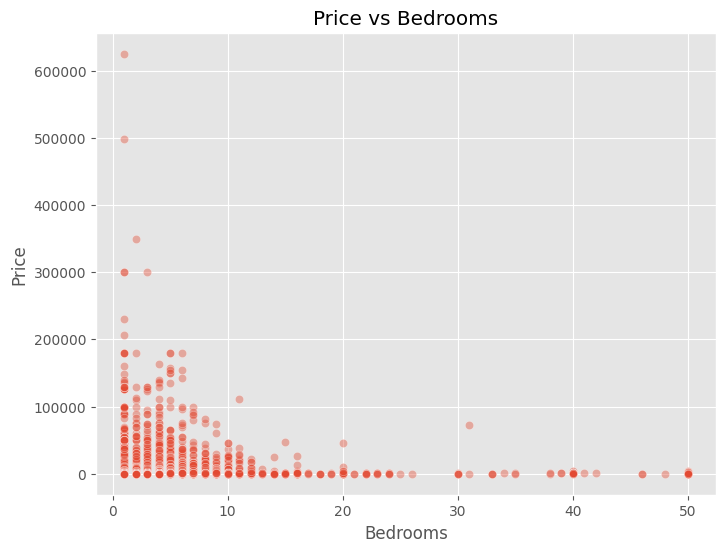

In [4]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="bedrooms",
    y="price",
    alpha=0.4
)

plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")

plt.show()

## Price vs Accomodates

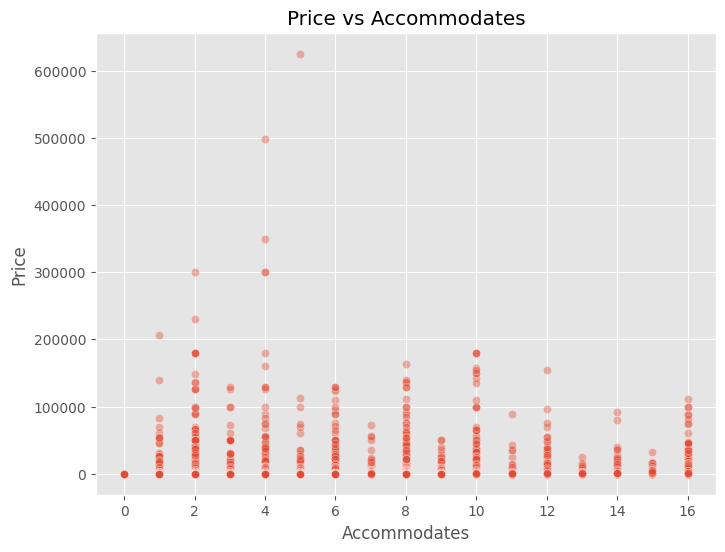

In [5]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="accommodates",
    y="price",
    alpha=0.4
)

plt.title("Price vs Accommodates")
plt.xlabel("Accommodates")
plt.ylabel("Price")

plt.show()

## Price vs Ratings

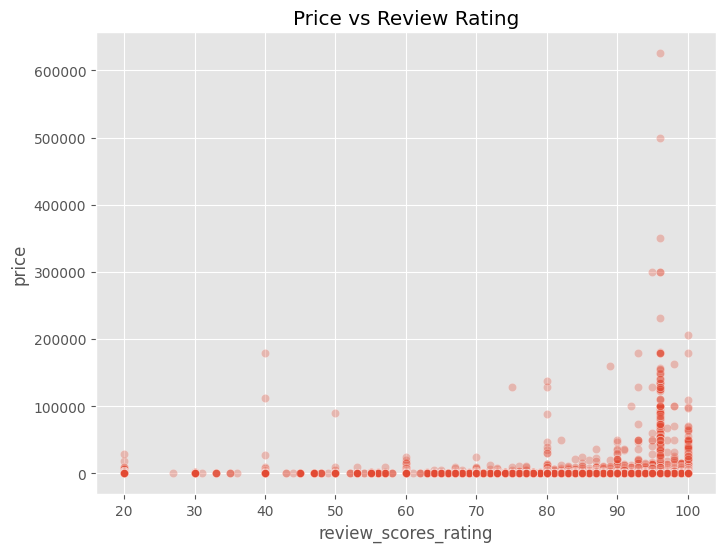

In [6]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="review_scores_rating",
    y="price",
    alpha=0.3
)

plt.title("Price vs Review Rating")

plt.show()

## Average Price by Room Type

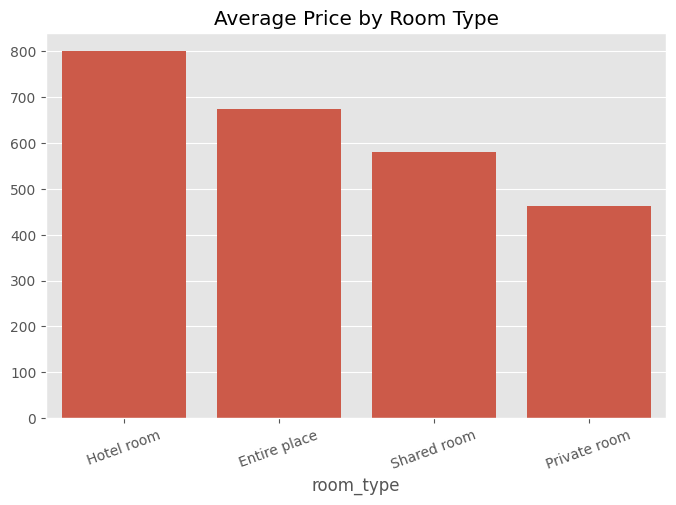

In [7]:
room_price = (
    df.groupby("room_type")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=room_price.index,
    y=room_price.values
)

plt.title("Average Price by Room Type")
plt.xticks(rotation=20)

plt.show()

## Average price by city

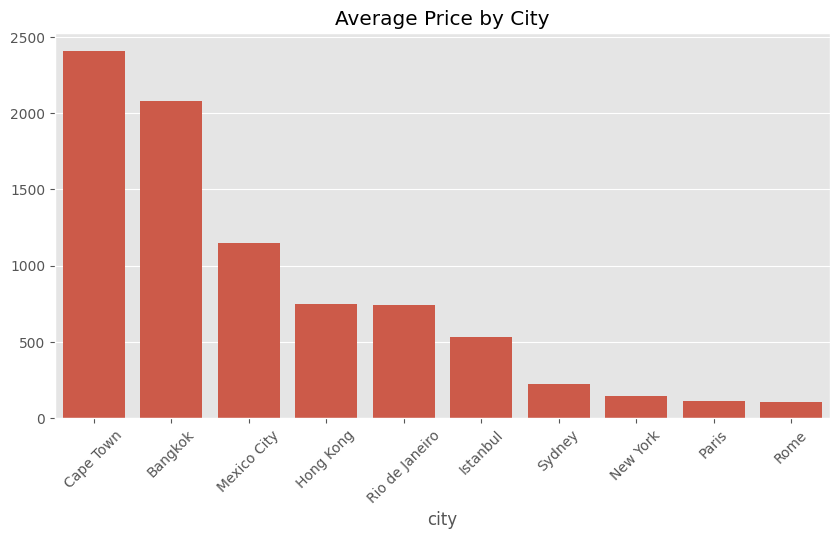

In [8]:
city_price = (
    df.groupby("city")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_price.index,
    y=city_price.values
)

plt.xticks(rotation=45)

plt.title("Average Price by City")

plt.show()

## Average Rating by City

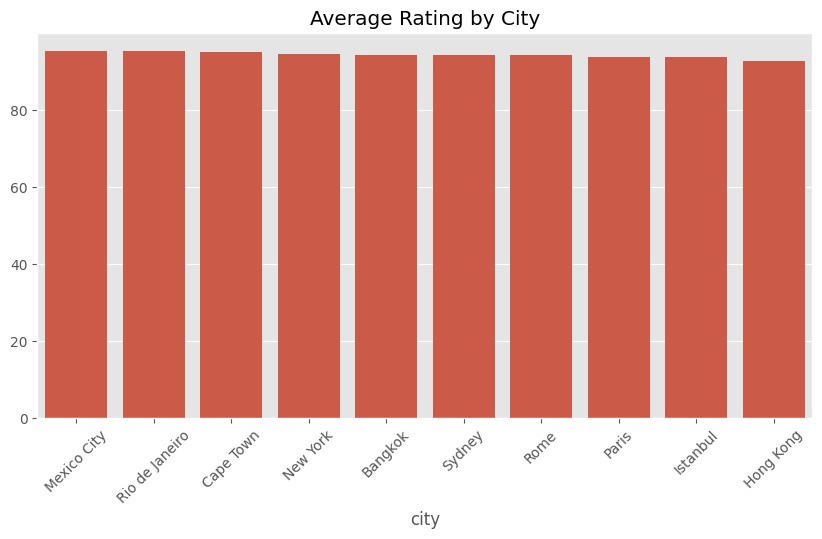

In [9]:
city_rating = (
    df.groupby("city")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=city_rating.index,
    y=city_rating.values
)

plt.xticks(rotation=45)

plt.title("Average Rating by City")

plt.show()

## Price distribution by Room Type

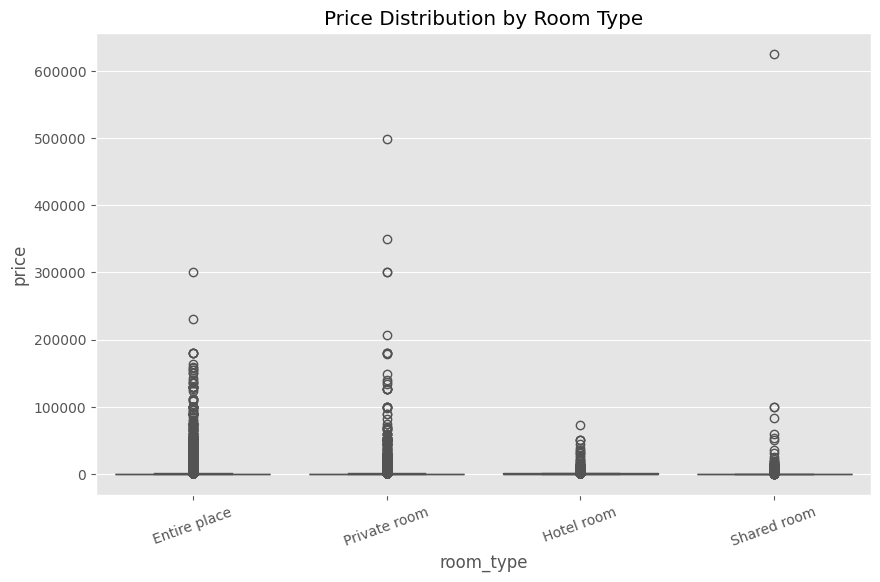

In [10]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="room_type",
    y="price"
)

plt.xticks(rotation=20)

plt.title("Price Distribution by Room Type")

plt.show()

## Price distribution by City

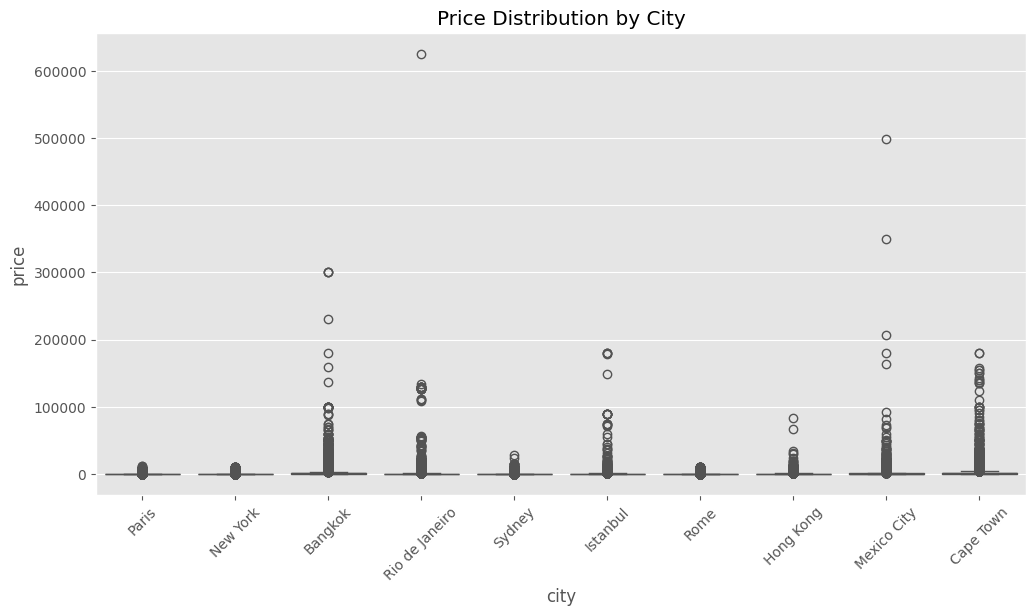

In [11]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="city",
    y="price"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by City")

plt.show()

## Average Rating by Room Type

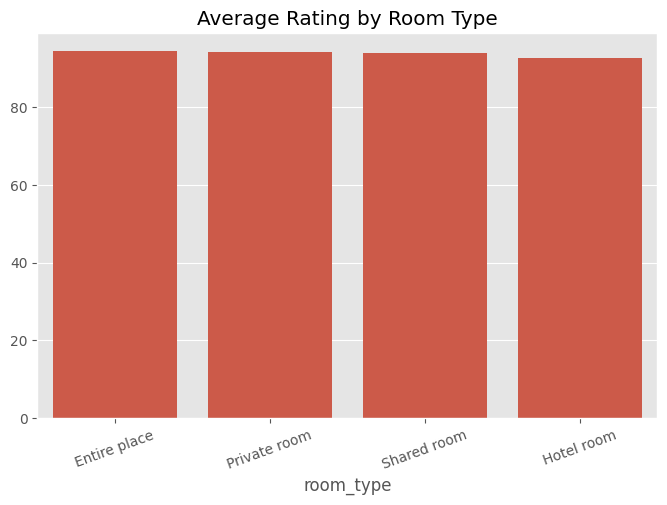

In [12]:
room_rating = (
    df.groupby("room_type")["review_scores_rating"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=room_rating.index,
    y=room_rating.values
)

plt.xticks(rotation=20)

plt.title("Average Rating by Room Type")

plt.show()

## Superhost vs Price

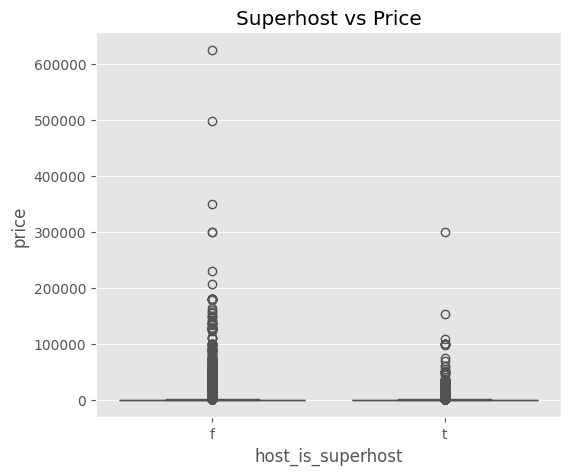

In [13]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="host_is_superhost",
    y="price"
)

plt.title("Superhost vs Price")

plt.show()

## Instant Bookable vs Price

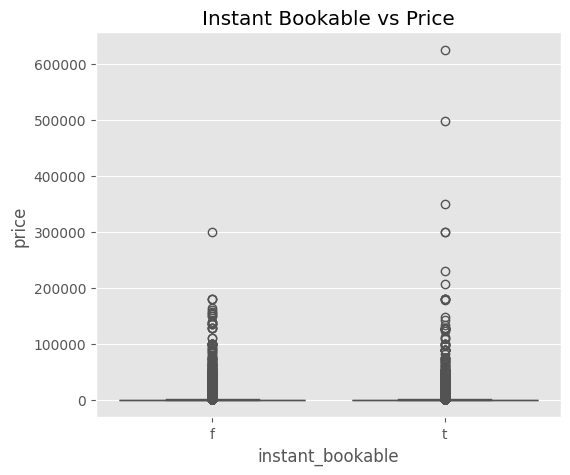

In [14]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="instant_bookable",
    y="price"
)

plt.title("Instant Bookable vs Price")

plt.show()

## Top 15 Property Types by Average Price

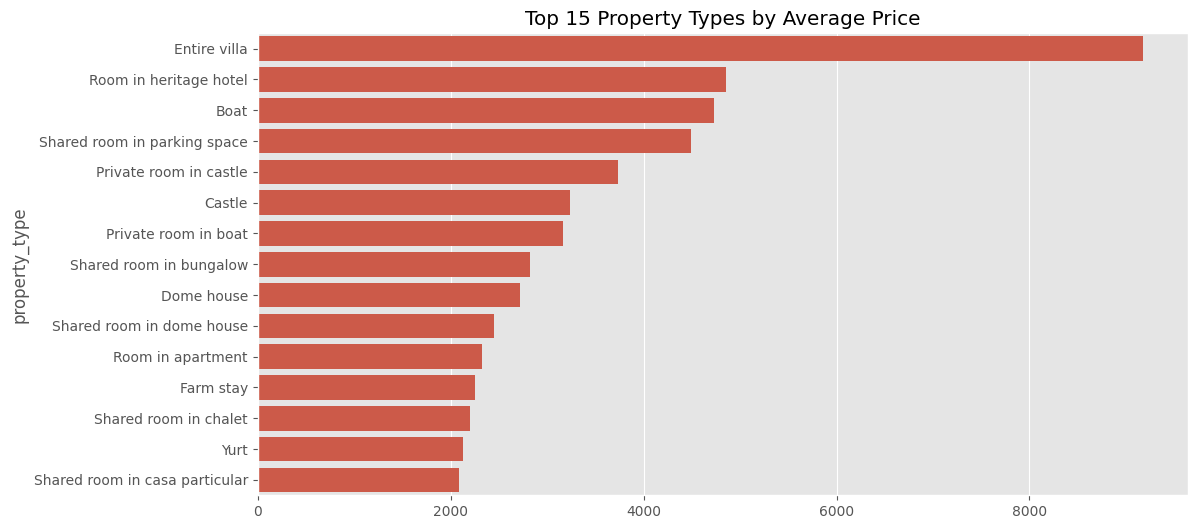

In [15]:
top_property = (
    df.groupby("property_type")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_property.values,
    y=top_property.index
)

plt.title("Top 15 Property Types by Average Price")

plt.show()

## Correlation matrix

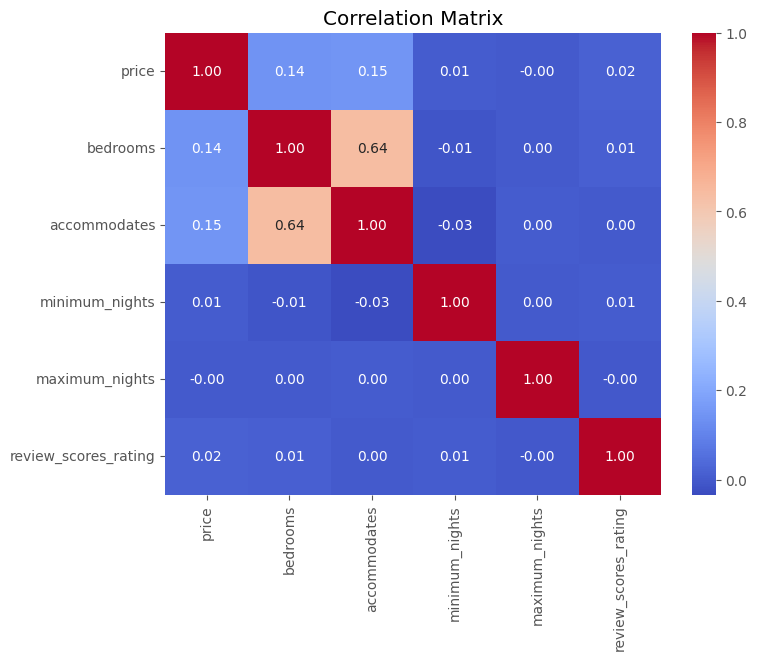

In [16]:
cols = [
    "price",
    "bedrooms",
    "accommodates",
    "minimum_nights",
    "maximum_nights",
    "review_scores_rating"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

# Business Insights

### Pricing
- Larger properties generally command higher prices.
- Entire homes/apartments are the highest-priced room type.
- Pricing varies significantly across cities.

### Ratings
- Ratings remain consistently high across most cities.
- Room type has only a small effect on ratings.

### Hosts
- Superhosts may have higher-priced listings.
- Instant-bookable listings can be compared with standard listings for pricing strategy.

### Market
- Property type influences average listing price.
- Accommodates and bedrooms show positive relationships with price.